# Visual Product Search Engine — CLIP Embedding + FAISS Indexing

This notebook builds the vector index for **Config A** and **Config B** of the ablation study.

---

### What this notebook does

For each gallery image, we compute a fused embedding:
```
v = alpha * CLIP_image(crop) + (1 - alpha) * CLIP_text(caption)
```
These vectors are stored in a FAISS index for fast nearest-neighbour search at query time.

---

### Ablation configs built here
| Config | alpha | Captions used? | Fine-tuned CLIP? |
|--------|-------|---------------|------------------|
| A      | 1.0   | No            | No (frozen)      |
| B      | 0.5   | Yes           | No (frozen)      |
| B      | 0.7   | Yes           | No (frozen)      |

Config C (fine-tuned CLIP) is built in a separate notebook after CLIP fine-tuning.

---

### Inputs
- `yolo-bbox-crops-v1` — bbox-cropped images + master_crops.csv
- `blipcaptionsoutput` — gallery_captions.json

### Outputs
- `faiss_index_A.bin` — FAISS index for Config A
- `faiss_index_B_alpha05.bin` — FAISS index for Config B, alpha=0.5
- `faiss_index_B_alpha07.bin` — FAISS index for Config B, alpha=0.7
- `gallery_metadata.csv` — maps index position to item_id and image_name
- `gallery_embeddings_A.npy` — raw vectors for Config A
- `gallery_embeddings_B_alpha05.npy` — raw vectors for Config B alpha=0.5
- `gallery_embeddings_B_alpha07.npy` — raw vectors for Config B alpha=0.7

## Step 1: Install and Import Libraries

In [1]:
!pip uninstall -y faiss faiss-gpu
!pip install ftfy regex transformers faiss-cpu Pillow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 73.3 MB/s eta 0:00:00


In [2]:
import os
import json
import numpy as np
import pandas as pd
import torch
import faiss
from PIL import Image
from tqdm import tqdm
from transformers import CLIPProcessor, CLIPModel
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device          : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
print(f'PyTorch version : {torch.__version__}')
print(f'FAISS version   : {faiss.__version__}')
print('All libraries imported!')

Device          : cuda
GPU             : Tesla T4
PyTorch version : 2.10.0+cu128
FAISS version   : 1.13.2
All libraries imported!


## Step 2: Paths and Config

In [3]:
# ── Input datasets ──────────────────────────────────────────────────────────
CROPS_DATASET   = '/kaggle/input/datasets/harshitabansal307/yolo-bbox-crops-v1'
CAPTIONS_DATASET = '/kaggle/input/datasets/harshitabansal307/blipcaptionsoutput'

# ── Output ──────────────────────────────────────────────────────────────────
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── CLIP model ──────────────────────────────────────────────────────────────
CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'

# ── Alpha values for Config B ────────────────────────────────────────────────
# Alpha controls image vs text weight: v = alpha*image + (1-alpha)*text
# alpha=1.0 → pure image (Config A)
# alpha=0.7 → 70% image, 30% text
# alpha=0.5 → equal image and text
ALPHA_VALUES = [1.0, 0.7, 0.5]

BATCH_SIZE = 64   # images per batch for CLIP encoding

# ── Verify paths ─────────────────────────────────────────────────────────────
for label, path in [('CROPS_DATASET', CROPS_DATASET), ('CAPTIONS_DATASET', CAPTIONS_DATASET)]:
    status = 'Found ✓' if os.path.exists(path) else 'NOT FOUND ✗'
    print(f'[{status}] {label}: {path}')

[Found ✓] CROPS_DATASET: /kaggle/input/datasets/harshitabansal307/yolo-bbox-crops-v1
[Found ✓] CAPTIONS_DATASET: /kaggle/input/datasets/harshitabansal307/blipcaptionsoutput


## Step 3: Load Gallery CSV and Captions

In [4]:
# Load master CSV and filter to gallery split
master_df = pd.read_csv(os.path.join(CROPS_DATASET, 'master_crops.csv'))
gallery_df = master_df[master_df['split'] == 'gallery'].reset_index(drop=True)

print(f'Total rows in master  : {len(master_df):,}')
print(f'Gallery rows          : {len(gallery_df):,}')

# Remap crop paths to dataset location
def remap_path(old_path):
    if pd.isna(old_path):
        return old_path
    # Handle both yolo_crops and bbox_crops folder names
    for prefix in ['/kaggle/working/', '/kaggle/input/']:
        if old_path.startswith(prefix):
            relative = old_path.replace(prefix, '')
            # Remove dataset name prefix if present
            for ds in ['yolocroppeddataset/', 'yolo-bbox-crops-v1/', 'datasets/harshitabansal307/yolo-bbox-crops-v1/']:
                relative = relative.replace(ds, '')
            return os.path.join(CROPS_DATASET, relative)
    return old_path

gallery_df['crop_path_new'] = gallery_df['crop_path'].apply(remap_path)
gallery_df['crop_exists']   = gallery_df['crop_path_new'].apply(
    lambda p: os.path.exists(p) if isinstance(p, str) else False
)

print(f'Gallery crops found   : {gallery_df["crop_exists"].sum():,} / {len(gallery_df):,}')

# If path remapping failed, try to find crops by image_name directly
if gallery_df['crop_exists'].sum() < len(gallery_df) * 0.9:
    print('\nPath remapping may have issues — trying direct path construction...')
    def direct_path(image_name):
        relative = image_name[4:] if image_name.startswith('img/') else image_name
        for subdir in ['data/bbox_crops', 'data/yolo_crops']:
            p = os.path.join(CROPS_DATASET, subdir, relative)
            if os.path.exists(p):
                return p
        return os.path.join(CROPS_DATASET, 'data/bbox_crops', relative)
    gallery_df['crop_path_new'] = gallery_df['image_name'].apply(direct_path)
    gallery_df['crop_exists']   = gallery_df['crop_path_new'].apply(os.path.exists)
    print(f'After direct path    : {gallery_df["crop_exists"].sum():,} / {len(gallery_df):,}')

print(f'\nSample paths:')
for p in gallery_df['crop_path_new'].head(2):
    print(f'  [{"OK" if os.path.exists(p) else "MISSING"}] {p}')

Total rows in master  : 52,712
Gallery rows          : 12,612
Gallery crops found   : 12,612 / 12,612

Sample paths:
  [OK] /kaggle/input/datasets/harshitabansal307/yolo-bbox-crops-v1/data/bbox_crops/WOMEN/Blouses_Shirts/id_00000001/02_1_front.jpg
  [OK] /kaggle/input/datasets/harshitabansal307/yolo-bbox-crops-v1/data/bbox_crops/WOMEN/Blouses_Shirts/id_00000001/02_3_back.jpg


In [5]:
# Load gallery captions
captions_path = os.path.join(CAPTIONS_DATASET, 'gallery_captions.json')
with open(captions_path, 'r') as f:
    gallery_captions = json.load(f)

print(f'Gallery captions loaded : {len(gallery_captions):,}')

# Check coverage — how many gallery images have captions
gallery_names = set(gallery_df['image_name'].tolist())
captioned     = gallery_names.intersection(set(gallery_captions.keys()))
print(f'Gallery images with captions: {len(captioned):,} / {len(gallery_names):,}')

# Show a few sample captions
print('\nSample captions:')
for name, cap in list(gallery_captions.items())[:3]:
    print(f'  {name.split("/")[-1]}: {cap}')

Gallery captions loaded : 12,612
Gallery images with captions: 12,612 / 12,612

Sample captions:
  02_1_front.jpg: a woman in black shorts and a white blouse
  02_3_back.jpg: the back view of a woman wearing a white blouse
  01_1_front.jpg: a woman wearing a tank top with the words snoop dogg on it


## Step 4: Load CLIP Model (Frozen)

In [6]:
print(f'Loading CLIP: {CLIP_MODEL_NAME}')

clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model     = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE)

# Freeze all — we are NOT training here
for param in clip_model.parameters():
    param.requires_grad = False
clip_model.eval()

print('CLIP loaded and frozen!')
print(f'Embedding dimension : {clip_model.config.projection_dim}')
EMBED_DIM = clip_model.config.projection_dim

Loading CLIP: openai/clip-vit-base-patch32


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded and frozen!
Embedding dimension : 512


## Step 5: Define Embedding Functions

In [7]:
def encode_images_batch(image_paths):
    """Encode a batch of image paths → normalised CLIP image embeddings."""
    images = []
    valid_indices = []
    for i, path in enumerate(image_paths):
        try:
            img = Image.open(path).convert('RGB')
            images.append(img)
            valid_indices.append(i)
        except Exception:
            pass

    if not images:
        return None, valid_indices

    inputs = clip_processor(images=images, return_tensors='pt', padding=True).to(DEVICE)
    with torch.no_grad():
        out = clip_model.get_image_features(**inputs)
        feats = out.pooler_output if hasattr(out, "pooler_output") and not isinstance(out, torch.Tensor) else out
    feats = feats / feats.norm(dim=-1, keepdim=True)   # L2 normalise
    return feats.cpu().numpy(), valid_indices


def encode_texts_batch(texts):
    """Encode a batch of text strings → normalised CLIP text embeddings."""
    inputs = clip_processor(
        text=texts,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=77
    ).to(DEVICE)
    with torch.no_grad():
        out = clip_model.get_text_features(**inputs)
        feats = out.pooler_output if hasattr(out, "pooler_output") and not isinstance(out, torch.Tensor) else out
    feats = feats / feats.norm(dim=-1, keepdim=True)   # L2 normalise
    return feats.cpu().numpy()


def fuse_embeddings(image_emb, text_emb, alpha):
    """Fuse image and text embeddings: v = alpha*image + (1-alpha)*text, then normalise."""
    fused = alpha * image_emb + (1 - alpha) * text_emb
    # Renormalise after fusion
    norms = np.linalg.norm(fused, axis=-1, keepdims=True)
    fused = fused / np.maximum(norms, 1e-8)
    return fused


print('Embedding functions defined ✓')

# Quick test
test_row = gallery_df[gallery_df['crop_exists']].iloc[0]
test_img_emb, _ = encode_images_batch([test_row['crop_path_new']])
test_txt_emb    = encode_texts_batch(['a white floral dress'])
print(f'Image embedding shape : {test_img_emb.shape}')
print(f'Text embedding shape  : {test_txt_emb.shape}')
print(f'Image emb norm        : {np.linalg.norm(test_img_emb[0]):.4f}  (should be ~1.0)')
print(f'Text emb norm         : {np.linalg.norm(test_txt_emb[0]):.4f}  (should be ~1.0)')

Embedding functions defined ✓
Image embedding shape : (1, 512)
Text embedding shape  : (1, 512)
Image emb norm        : 1.0000  (should be ~1.0)
Text emb norm         : 1.0000  (should be ~1.0)


## Step 6: Compute All Gallery Image Embeddings

We compute image embeddings once and reuse them for all alpha values.
This avoids running CLIP image encoder 3 times.

In [8]:
valid_gallery = gallery_df[gallery_df['crop_exists']].reset_index(drop=True)
n = len(valid_gallery)
print(f'Computing image embeddings for {n:,} gallery images...')

all_image_embs = np.zeros((n, EMBED_DIM), dtype=np.float32)
failed_indices = []

for batch_start in tqdm(range(0, n, BATCH_SIZE), desc='Image embeddings'):
    batch = valid_gallery.iloc[batch_start : batch_start + BATCH_SIZE]
    paths = batch['crop_path_new'].tolist()

    embs, valid_idx = encode_images_batch(paths)
    if embs is None:
        failed_indices.extend(range(batch_start, batch_start + len(paths)))
        continue

    for local_i, global_i in enumerate(valid_idx):
        all_image_embs[batch_start + global_i] = embs[local_i]

print(f'\nImage embeddings done!')
print(f'Shape  : {all_image_embs.shape}')
print(f'Failed : {len(failed_indices)}')

Computing image embeddings for 12,612 gallery images...


Image embeddings: 100%|██████████| 198/198 [02:16<00:00,  1.45it/s]


Image embeddings done!
Shape  : (12612, 512)
Failed : 0


## Step 7: Compute All Gallery Text Embeddings (from BLIP-2 captions)

In [9]:
print(f'Computing text embeddings for {n:,} gallery captions...')

all_text_embs = np.zeros((n, EMBED_DIM), dtype=np.float32)
missing_captions = 0

for batch_start in tqdm(range(0, n, BATCH_SIZE), desc='Text embeddings'):
    batch = valid_gallery.iloc[batch_start : batch_start + BATCH_SIZE]
    texts = []
    for _, row in batch.iterrows():
        cap = gallery_captions.get(row['image_name'], '')
        if not cap:
            cap = 'a clothing item'   # fallback if caption missing
            missing_captions += 1
        texts.append(cap)

    embs = encode_texts_batch(texts)
    all_text_embs[batch_start : batch_start + len(texts)] = embs

print(f'\nText embeddings done!')
print(f'Shape            : {all_text_embs.shape}')
print(f'Missing captions : {missing_captions}  (used fallback text)')

Computing text embeddings for 12,612 gallery captions...


Text embeddings: 100%|██████████| 198/198 [00:07<00:00, 26.13it/s]


Text embeddings done!
Shape            : (12612, 512)
Missing captions : 0  (used fallback text)


## Step 8: Build Fused Embeddings and FAISS Indexes for Each Alpha

For each alpha value:
1. Fuse image + text embeddings
2. Save embeddings as .npy
3. Build FAISS flat index (exact cosine similarity search)
4. Save index as .bin

In [10]:
for alpha in ALPHA_VALUES:
    print(f'\n--- Alpha = {alpha} ---')

    # Determine config label
    if alpha == 1.0:
        label = 'A'
        alpha_str = 'alpha10'
    elif alpha == 0.7:
        label = 'B'
        alpha_str = 'alpha07'
    else:
        label = 'B'
        alpha_str = f'alpha{int(alpha*10):02d}'

    # Compute fused embeddings
    if alpha == 1.0:
        # Config A — pure image, no text at all
        fused = all_image_embs.copy()
        print(f'Config A: pure image embeddings (no text)')
    else:
        fused = fuse_embeddings(all_image_embs, all_text_embs, alpha)
        print(f'Config B: {alpha*100:.0f}% image + {(1-alpha)*100:.0f}% text')

    print(f'Fused shape : {fused.shape}')
    print(f'Sample norm : {np.linalg.norm(fused[0]):.4f}  (should be ~1.0)')

    # Save raw embeddings
    emb_path = os.path.join(OUTPUT_DIR, f'gallery_embeddings_{label}_{alpha_str}.npy')
    np.save(emb_path, fused)
    print(f'Saved embeddings → {emb_path}')

    # Build FAISS flat inner product index
    # Since vectors are L2 normalised, inner product = cosine similarity
    index = faiss.IndexFlatIP(EMBED_DIM)
    index.add(fused.astype(np.float32))
    print(f'FAISS index built — {index.ntotal:,} vectors')

    # Save FAISS index
    index_path = os.path.join(OUTPUT_DIR, f'faiss_index_{label}_{alpha_str}.bin')
    faiss.write_index(index, index_path)
    print(f'Saved FAISS index → {index_path}')

print('\nAll indexes built!')


--- Alpha = 1.0 ---
Config A: pure image embeddings (no text)
Fused shape : (12612, 512)
Sample norm : 1.0000  (should be ~1.0)
Saved embeddings → /kaggle/working/gallery_embeddings_A_alpha10.npy
FAISS index built — 12,612 vectors
Saved FAISS index → /kaggle/working/faiss_index_A_alpha10.bin

--- Alpha = 0.7 ---
Config B: 70% image + 30% text
Fused shape : (12612, 512)
Sample norm : 1.0000  (should be ~1.0)
Saved embeddings → /kaggle/working/gallery_embeddings_B_alpha07.npy
FAISS index built — 12,612 vectors
Saved FAISS index → /kaggle/working/faiss_index_B_alpha07.bin

--- Alpha = 0.5 ---
Config B: 50% image + 50% text
Fused shape : (12612, 512)
Sample norm : 1.0000  (should be ~1.0)
Saved embeddings → /kaggle/working/gallery_embeddings_B_alpha05.npy
FAISS index built — 12,612 vectors
Saved FAISS index → /kaggle/working/faiss_index_B_alpha05.bin

All indexes built!


## Step 9: Save Gallery Metadata

This CSV maps each FAISS index position (row number) back to item_id and image_name.
It is required for evaluation — to check if a retrieved item matches the query's item_id.

In [11]:
metadata_df = valid_gallery[['image_name', 'item_id', 'split', 'clothes_type', 'crop_path_new']].copy()
metadata_df = metadata_df.rename(columns={'crop_path_new': 'crop_path'})
metadata_df['faiss_index_pos'] = range(len(metadata_df))

meta_path = os.path.join(OUTPUT_DIR, 'gallery_metadata.csv')
metadata_df.to_csv(meta_path, index=False)

print(f'Gallery metadata saved → {meta_path}')
print(f'Rows : {len(metadata_df):,}')
print(f'Columns : {metadata_df.columns.tolist()}')
print(metadata_df.head())

Gallery metadata saved → /kaggle/working/gallery_metadata.csv
Rows : 12,612
Columns : ['image_name', 'item_id', 'split', 'clothes_type', 'crop_path', 'faiss_index_pos']
                                          image_name      item_id    split  \
0  img/WOMEN/Blouses_Shirts/id_00000001/02_1_fron...  id_00000001  gallery   
1  img/WOMEN/Blouses_Shirts/id_00000001/02_3_back...  id_00000001  gallery   
2    img/WOMEN/Tees_Tanks/id_00000007/01_1_front.jpg  id_00000007  gallery   
3     img/WOMEN/Tees_Tanks/id_00000007/01_3_back.jpg  id_00000007  gallery   
4        img/WOMEN/Dresses/id_00000008/02_3_back.jpg  id_00000008  gallery   

   clothes_type                                          crop_path  \
0             1  /kaggle/input/datasets/harshitabansal307/yolo-...   
1             1  /kaggle/input/datasets/harshitabansal307/yolo-...   
2             1  /kaggle/input/datasets/harshitabansal307/yolo-...   
3             1  /kaggle/input/datasets/harshitabansal307/yolo-...   
4           

## Step 10: Quick Retrieval Sanity Check

Pick a random gallery image, search the index, and check if the top results are the same item.

Query image   : 04_1_front.jpg
Query item_id : id_00004024

Top 6 results:
  Rank 1: item_id=id_00004024  score=1.0000  ✓ MATCH
  Rank 2: item_id=id_00002056  score=0.9572  ✗
  Rank 3: item_id=id_00002226  score=0.9494  ✗
  Rank 4: item_id=id_00007769  score=0.9492  ✗
  Rank 5: item_id=id_00007846  score=0.9463  ✗
  Rank 6: item_id=id_00004551  score=0.9456  ✗


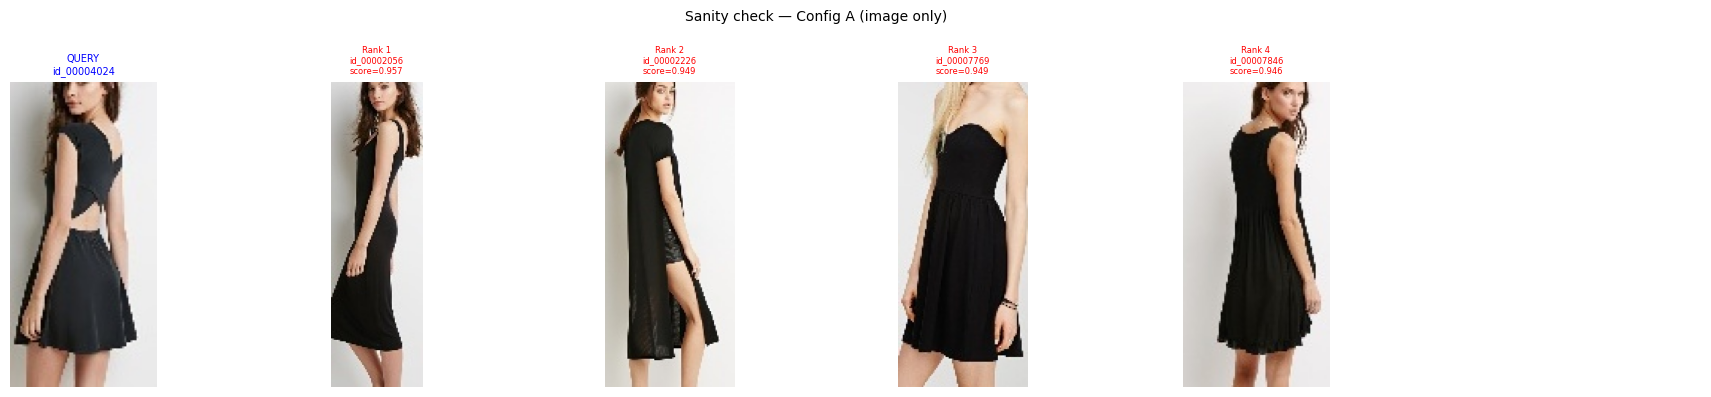

In [12]:
import matplotlib.pyplot as plt

# Load Config A index for sanity check
test_index = faiss.read_index(os.path.join(OUTPUT_DIR, 'faiss_index_A_alpha10.bin'))
test_embs  = np.load(os.path.join(OUTPUT_DIR, 'gallery_embeddings_A_alpha10.npy'))

# Pick a random query from gallery
query_row = valid_gallery.sample(1, random_state=42).iloc[0]
query_idx = query_row.name
query_emb = test_embs[query_idx:query_idx+1].astype(np.float32)

# Search top 6
distances, indices = test_index.search(query_emb, 6)

print(f'Query image   : {query_row["image_name"].split("/")[-1]}')
print(f'Query item_id : {query_row["item_id"]}')
print()
print('Top 6 results:')
for rank, (idx, dist) in enumerate(zip(indices[0], distances[0])):
    result_row = metadata_df.iloc[idx]
    match = '✓ MATCH' if result_row['item_id'] == query_row['item_id'] else '✗'
    print(f'  Rank {rank+1}: item_id={result_row["item_id"]}  score={dist:.4f}  {match}')

# Visual check
fig, axes = plt.subplots(1, 6, figsize=(18, 4))
query_img = Image.open(query_row['crop_path_new']).convert('RGB')
axes[0].imshow(query_img)
axes[0].set_title(f'QUERY\n{query_row["item_id"]}', fontsize=7, color='blue')
axes[0].axis('off')

for i, idx in enumerate(indices[0][1:5]):
    result_row = metadata_df.iloc[idx]
    try:
        img = Image.open(result_row['crop_path']).convert('RGB')
        match = result_row['item_id'] == query_row['item_id']
        color = 'green' if match else 'red'
        axes[i+1].imshow(img)
        axes[i+1].set_title(f'Rank {i+1}\n{result_row["item_id"]}\nscore={distances[0][i+1]:.3f}', fontsize=6, color=color)
        axes[i+1].axis('off')
    except:
        axes[i+1].axis('off')

axes[5].axis('off')
plt.suptitle('Sanity check — Config A (image only)', fontsize=10)
plt.tight_layout()
plt.show()

## Step 11: Final Summary

In [13]:
print('=' * 60)
print('     CLIP EMBEDDING + FAISS INDEXING COMPLETE')
print('=' * 60)
print(f'  CLIP model          : {CLIP_MODEL_NAME}')
print(f'  Gallery images      : {len(valid_gallery):,}')
print(f'  Embedding dimension : {EMBED_DIM}')
print()
print('  Files saved:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith(('.bin', '.npy', '.csv')):
        size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1e6
        print(f'    {f}  ({size:.1f} MB)')
print()
print('  Indexes built:')
print('    faiss_index_A_alpha10.bin   → Config A (alpha=1.0, image only)')
print('    faiss_index_B_alpha07.bin   → Config B (alpha=0.7)')
print('    faiss_index_B_alpha05.bin   → Config B (alpha=0.5)')
print()
print('  Next steps:')
print('    1. Save this output as a Kaggle dataset (clip-indexes-ab)')
print('    2. Run evaluation notebook to get Recall@K, NDCG@K, mAP@K')
print('    3. Run CLIP fine-tuning notebook for Config C')
print('=' * 60)

     CLIP EMBEDDING + FAISS INDEXING COMPLETE
  CLIP model          : openai/clip-vit-base-patch32
  Gallery images      : 12,612
  Embedding dimension : 512

  Files saved:
    faiss_index_A_alpha10.bin  (25.8 MB)
    faiss_index_B_alpha05.bin  (25.8 MB)
    faiss_index_B_alpha07.bin  (25.8 MB)
    gallery_embeddings_A_alpha10.npy  (25.8 MB)
    gallery_embeddings_B_alpha05.npy  (25.8 MB)
    gallery_embeddings_B_alpha07.npy  (25.8 MB)
    gallery_metadata.csv  (2.4 MB)

  Indexes built:
    faiss_index_A_alpha10.bin   → Config A (alpha=1.0, image only)
    faiss_index_B_alpha07.bin   → Config B (alpha=0.7)
    faiss_index_B_alpha05.bin   → Config B (alpha=0.5)

  Next steps:
    1. Save this output as a Kaggle dataset (clip-indexes-ab)
    2. Run evaluation notebook to get Recall@K, NDCG@K, mAP@K
    3. Run CLIP fine-tuning notebook for Config C
